# ML - Aprendizaje No Supervisado
## K-Means con Dataset Iris — 4 Variables

El aprendizaje no supervisado busca **descubrir patrones ocultos** en los datos sin necesidad de etiquetas. A diferencia del aprendizaje supervisado donde los datos ya tienen respuestas, aquí el algoritmo agrupa los datos por similitud por sí solo.

## Descripción del Dataset: Iris

### ¿De qué se trata?

El dataset **Iris** es uno de los más famosos en Machine Learning. Contiene mediciones físicas de **150 flores** pertenecientes a 3 especies distintas de la planta Iris, con 50 flores por especie. Fue introducido por el biólogo Ronald Fisher en 1936.

### ¿Qué contiene?

| Columna | Tipo | Descripción |
|---|---|---|
| **sepal_length** | Numérico | Longitud del sépalo en cm |
| **sepal_width** | Numérico | Ancho del sépalo en cm |
| **petal_length** | Numérico | Longitud del pétalo en cm |
| **petal_width** | Numérico | Ancho del pétalo en cm |
| **species** | Categórico | Especie: Iris-setosa, Iris-versicolor, Iris-virginica |

### ¿Para qué sirve?

El objetivo es aplicar **K-Means Clustering con las 4 variables numéricas** para ver si el algoritmo es capaz de **descubrir las 3 especies por sí solo**, sin conocer ninguna etiqueta de especie.

### Columnas utilizadas en este notebook (4 variables)

Se usan **todas las columnas numéricas** del dataset:
- **`sepal_length`** → longitud del sépalo
- **`sepal_width`** → ancho del sépalo
- **`petal_length`** → longitud del pétalo
- **`petal_width`** → ancho del pétalo

Con 4 dimensiones no se puede visualizar directamente, por lo que usamos **PCA** (Análisis de Componentes Principales) para reducir a 2D y poder graficar los clusters.

## 1. Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga del archivo iris.txt (sin encabezado, separado por comas)
df = pd.read_csv('iris.txt', header=None,
                 names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

print("Primeras filas del dataset:")
print(df.head(10))
print(f"\nDimensiones: {df.shape[0]} flores, {df.shape[1]} columnas")
print(f"\nEspecies únicas: {df['species'].unique()}")
print("\nEstadísticas descriptivas:")
print(df.describe())

Primeras filas del dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa

Dimensiones: 150 flores, 5 columnas

Especies únicas: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Estadísticas descriptivas:
       sepal_length  sepal_width  petal_l

## 2. Selección de las 4 Variables Numéricas

In [2]:
# Usamos TODAS las 4 columnas numéricas
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

print("Shape de X:", X.shape)  # (150, 4)
print("Primeros 5 valores:\n", X[:5])

Shape de X: (150, 4)
Primeros 5 valores:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 3. Entrenamiento K-Means (k=3)

In [3]:
from sklearn.cluster import KMeans

k = 3  # 3 clusters = 3 especies de iris
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

print("Etiquetas asignadas (primeras 20):", y_pred[:20])
print("\nCentroides encontrados (en el espacio de 4 dimensiones):")
print(pd.DataFrame(kmeans.cluster_centers_,
                   columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']))

Etiquetas asignadas (primeras 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Centroides encontrados (en el espacio de 4 dimensiones):
   sepal_length  sepal_width  petal_length  petal_width
0      6.853846     3.076923      5.715385     2.053846
1      5.006000     3.418000      1.464000     0.244000
2      5.883607     2.740984      4.388525     1.434426


## 4. Reducción a 2D con PCA para Visualización

Como tenemos 4 dimensiones no podemos graficarlas directamente. Usamos **PCA (Principal Component Analysis)** para comprimir las 4 variables en 2 componentes principales que conservan la mayor varianza posible, permitiéndonos visualizar los clusters en 2D.

In [4]:
from sklearn.decomposition import PCA

# Reducimos de 4D a 2D conservando la mayor varianza posible
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza total conservada: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Shape después de PCA: {X_2d.shape}")

Varianza explicada por cada componente: [0.92461621 0.05301557]
Varianza total conservada: 97.76%
Shape después de PCA: (150, 2)


In [5]:
a=np.array([[1,2,3,4,5],[6,7,8,9,10],[11,12,13,14,15]])
a1=a[:,0]
print(a1)

[ 1  6 11]


## 5. Funciones de Visualización

In [6]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=4)

def plot_centroids(centroids, circle_color='w', cross_color='k'):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000,
                             show_centroids=True, show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap='Pastel2')
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel('Componente Principal 1 (PCA)', fontsize=13)
    if show_ylabels:
        plt.ylabel('Componente Principal 2 (PCA)', fontsize=13)

## 6. K-Means sobre los Datos Reducidos (2D) y Fronteras de Decisión

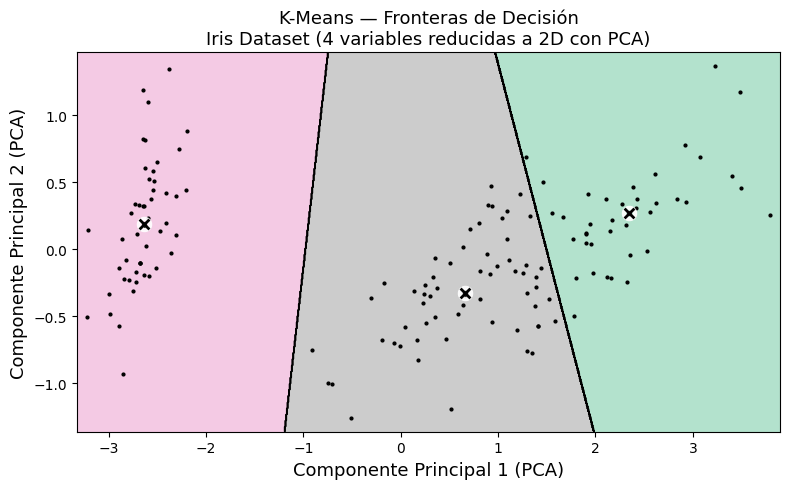

In [7]:
# Entrenamos K-Means sobre los datos en 2D (para poder graficar fronteras)
kmeans_2d = KMeans(n_clusters=3, random_state=42)
kmeans_2d.fit(X_2d)

plt.figure(figsize=(8, 5))
plot_decision_boundaries(kmeans_2d, X_2d)
plt.title('K-Means — Fronteras de Decisión\nIris Dataset (4 variables reducidas a 2D con PCA)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Predicción de Nuevas Flores

In [8]:
# Predecir el cluster de nuevas flores [sepal_length, sepal_width, petal_length, petal_width]
X_new = np.array([[5.0, 3.5, 1.4, 0.2],   # probable setosa
                  [6.5, 2.8, 4.5, 1.5],   # probable versicolor
                  [7.0, 3.0, 6.0, 2.1]])  # probable virginica

predicciones = kmeans.predict(X_new)
for i, pred in enumerate(predicciones):
    print(f"Flor {i+1} {X_new[i]} → Cluster {pred}")

Flor 1 [5.  3.5 1.4 0.2] → Cluster 1
Flor 2 [6.5 2.8 4.5 1.5] → Cluster 2
Flor 3 [7.  3.  6.  2.1] → Cluster 0


## 8. Comparación: Clusters vs Especies Reales

In [9]:
df['cluster'] = y_pred
print("Distribución de especies reales por cluster encontrado:")
print(pd.crosstab(df['cluster'], df['species']))
print("\nInterpretación: cada cluster debería corresponder mayoritariamente a una especie.")

Distribución de especies reales por cluster encontrado:
species  Iris-setosa  Iris-versicolor  Iris-virginica
cluster                                              
0                  0                3              36
1                 50                0               0
2                  0               47              14

Interpretación: cada cluster debería corresponder mayoritariamente a una especie.
